In [44]:
!pip install --no-cache-dir git+https://github.com/jgrss/geowombat

  Running command git clone -q https://github.com/jgrss/geowombat 'C:\Users\flopes1\AppData\Local\Temp\pip-req-build-ibye76t_'
ERROR: Some build dependencies for git+https://github.com/jgrss/geowombat conflict with the backend dependencies: cython==3.0.0b1 is incompatible with cython>=0.29.0.



  Cloning https://github.com/jgrss/geowombat to c:\users\flopes1\appdata\local\temp\pip-req-build-ibye76t_
  Resolved https://github.com/jgrss/geowombat to commit aab82a88d77dc9644c15b341c79d255e8d990de1
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'


In [ ]:
#IMPORT THE LIBRARIES NEEDED
import rasterio
import numpy as np
from rasterio.plot import show
import fiona
import rasterio.mask
from matplotlib import pyplot
import pandas as pd
import glob
import os
import geowombat as gw
from raster4ml.extraction import batch_extract_by_polygons

In [ ]:
with gw.open([l8_224078_20200518, l8_224078_20200518],
            band_names=['blue', 'green', 'red'],
            time_names=['t1', 't2'],
            stack_dim='time') as src:
    print(src)

In [35]:
#Considering the Chacabuco field
# 6 dates
# Open the raster images
raw_0830 = rasterio.open(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\08-30-2021\LARGO1_0830.tif")
pixel_values_0830 = raw_0830.read()
image_norm_0830 = (pixel_values_0830 - pixel_values_0830.min()) / (pixel_values_0830.max() - pixel_values_0830.min())
"""
Now we use the show function from rasterio, passing in the image to display it.
Note that this function expects the numpy array to be either a float ranging from 0 to 1, or an uint8 ranging from 0 to 255. 
Since our image is an uint16, we first normalize in order for it to render properly.
"""
show(image_norm_0830)
raw_0924 = rasterio.open(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\LARGO_1_0924_ALL.tif")
raw_1005 = rasterio.open(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-05-2021\LARGO_1_1005.tif")
raw_1007 = rasterio.open(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-07-2021\LARGO_1_1007_ALL.tif")
raw_1026 = rasterio.open(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-26-2021\LARGO_1_1026_ALLN.tif")
raw_1117 = rasterio.open(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\LARGO_1_1117_ALL.tif")

SyntaxError: EOF while scanning triple-quoted string literal (<ipython-input-35-524320785e09>, line 26)

TypeError: Invalid shape (10140, 15157, 5) for image data

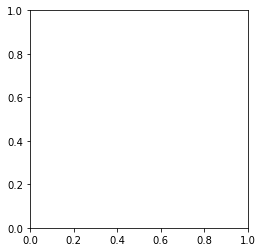

In [19]:
pixel_values_0924 = raw_0924.read()
pixel_values_1005 = raw_1005.read()
pixel_values_1007 = raw_1007.read()
pixel_values_1026 = raw_1026.read()
pixel_values_1117 = raw_1117.read()

#SAVE THE BANDS INTO VARIABLES
band_blue = pixel_values_0830[0]
band_green = pixel_values_0830[1]
band_red = pixel_values_0830[2]
band_rede = pixel_values_0830[3]
band_nir = pixel_values_0830[4]

print(pixel_values_0830)"""

In [ ]:
profile = image_file.profile
profile.update(
  dtype=rasterio.float32,
  count=1)

#CALCULATE INDEXES AND CREATE A RASTER OF EACH OF THEM, THEN SAVE THEM INTO A FOLDER
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\blue.tif", 'w', **profile) as rst:
    rst.write_band(1, band_blue.astype('float32'))
    
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\green.tif", 'w', **profile) as rst:
    rst.write_band(1, band_green.astype('float32'))
    
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\red.tif", 'w', **profile) as rst:
    rst.write_band(1, band_red.astype('float32'))
    
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\rede.tif", 'w', **profile) as rst:
    rst.write_band(1, band_rede.astype('float32'))
    
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\nir.tif", 'w', **profile) as rst:
    rst.write_band(1, band_nir.astype('float32'))

NDVI = (band_nir - band_red) / (band_nir + band_red)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\NDVI.tif", 'w', **profile) as rst:
    rst.write_band(1, NDVI.astype('float32'))

GNDVI = (band_nir-band_green)/(band_nir+band_green)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\GNDVI.tif", 'w', **profile) as rst:
    rst.write_band(1, GNDVI.astype('float32'))

RVI_1 = band_nir/band_red
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\RVI_1.tif", 'w', **profile) as rst:
    rst.write_band(1, RVI_1.astype('float32'))

GCI = (band_nir/band_green)-1.0
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\GCI.tif", 'w', **profile) as rst:
    rst.write_band(1, GCI.astype('float32'))

RGVI = band_red/band_green
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\RGVI.tif", 'w', **profile) as rst:
    rst.write_band(1, RGVI.astype('float32'))

DVI = band_nir-band_red
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\DVI.tif", 'w', **profile) as rst:
    rst.write_band(1, DVI.astype('float32'))

L = 0.5
SAVI = ((band_nir-band_red)/(band_nir+band_red+L))*(1.0+L)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\SAVI.tif", 'w', **profile) as rst:
    rst.write_band(1, SAVI.astype('float32'))

MSAVI = 0.5*((2.0*band_nir)+1.0-np.sqrt(np.square(2.0*band_nir+1.0)-8.0*(band_nir-band_red)))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\MSAVI.tif", 'w', **profile) as rst:
    rst.write_band(1, MSAVI.astype('float32'))

OSAVI = (band_nir-band_red)/(band_nir+band_red+0.16)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\OSAVI.tif", 'w', **profile) as rst:
    rst.write_band(1, OSAVI.astype('float32'))

RDVI = np.sqrt((np.square(band_nir-band_red))/(band_nir+band_red))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\RDVI.tif", 'w', **profile) as rst:
    rst.write_band(1, RDVI.astype('float32'))

TVI = 60.0*(band_nir-band_green)-100.0*(band_red-band_green)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\TVI.tif", 'w', **profile) as rst:
    rst.write_band(1, TVI.astype('float32'))

a = 0.96916 
b = 0.084726
TSAVI = (a*(band_nir-a*band_red-b))/(a*band_nir+band_red-a*b)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\TSAVI.tif", 'w', **profile) as rst:
    rst.write_band(1, TSAVI.astype('float32'))

PVI = (band_nir-a*band_red-b)/np.sqrt(1+np.square(a))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\TSAVI.tif", 'w', **profile) as rst:
    rst.write_band(1, TSAVI.astype('float32'))

SAVI_2 = band_nir/(band_red-(b/a))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\SAVI_2.tif", 'w', **profile) as rst:
    rst.write_band(1, SAVI_2.astype('float32'))

X = 0.08
ATSAVI= (a*(-a*band_red-b))/(a*band_nir+band_red-a*b+X*(1+np.square(a)))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\ATSAVI.tif", 'w', **profile) as rst:
    rst.write_band(1, ATSAVI.astype('float32'))

NDWI = (band_green-band_nir)/(band_green+band_nir)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\NDWI.tif", 'w', **profile) as rst:
    rst.write_band(1, NDWI.astype('float32'))

NPCI = (band_red-band_blue)/(band_red+band_blue)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\NPCI.tif", 'w', **profile) as rst:
    rst.write_band(1, NPCI.astype('float32'))

SRPI = band_blue/band_red
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\SRPI.tif", 'w', **profile) as rst:
    rst.write_band(1, SRPI.astype('float32'))

RVI_2 = band_nir/band_green
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\RVI_2.tif", 'w', **profile) as rst:
    rst.write_band(1, RVI_2.astype('float32'))

MCARI = (band_rede-band_red-0.2*(band_rede-band_green))*(band_rede/band_red)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\MCARI.tif", 'w', **profile) as rst:
    rst.write_band(1, MCARI.astype('float32'))

MCARI_1 = 1.2*(2.5*(band_nir-band_red)-1.3*(band_nir-band_green))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\MCARI_1.tif", 'w', **profile) as rst:
    rst.write_band(1, MCARI_1.astype('float32'))

MCARI_2 = 1.5*(2.5*(band_nir-band_red)-1.3*(band_nir-band_green))*(np.square(2.0*band_nir+1))-(6.0*band_nir-5.0*band_red)-0.5
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\MCARI_2.tif", 'w', **profile) as rst:
    rst.write_band(1, MCARI_2.astype('float32'))

MTVI_1 = 1.2*(1.2*(band_nir-band_green)-2.5*(band_red-band_green))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\MTVI_1.tif", 'w', **profile) as rst:
    rst.write_band(1, MTVI_1.astype('float32'))

MTVI_2 = 1.5*(1.2*(band_nir-band_green)-2.5*(band_red-band_green))*(np.square(2*band_nir+1))-(6.0*band_nir-5.0*band_red)-0.5
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\MTVI_2.tif", 'w', **profile) as rst:
    rst.write_band(1, MTVI_2.astype('float32'))

R_MCARI_MTVI2 = ((band_rede-band_red-0.2*(band_rede-band_green))*(band_rede/band_red))/(1.5*(1.2*(band_nir-band_green)-2.5*(band_red-band_green))*(np.square(2*band_nir+1))-(6.0*band_nir-5.0*band_red)-0.5)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\R_MCARI_MTVI2.tif", 'w', **profile) as rst:
    rst.write_band(1, R_MCARI_MTVI2.astype('float32'))

EVI = (band_nir-band_red)/(band_nir+6.0*band_red-7.5*band_blue+1.0)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\EVI.tif", 'w', **profile) as rst:
    rst.write_band(1, EVI.astype('float32'))

DATT = (band_nir-band_rede)/(band_nir-band_red)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\DATT.tif", 'w', **profile) as rst:
    rst.write_band(1, DATT.astype('float32'))

NDCI = (band_rede-band_green)/(band_rede+band_green)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\NDCI.tif", 'w', **profile) as rst:
    rst.write_band(1, NDCI.astype('float32'))

PSRI = (band_red-band_green)/band_rede
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\PSRI.tif", 'w', **profile) as rst:
    rst.write_band(1, PSRI.astype('float32'))

SIPI = (band_nir-band_blue)/(band_nir+band_red)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\SIPI.tif", 'w', **profile) as rst:
    rst.write_band(1, SIPI.astype('float32'))

SPVI = 0.4*3.7*(band_nir-band_red)-1.2*np.absolute(band_green-band_red)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\SPVI.tif", 'w', **profile) as rst:
    rst.write_band(1, SPVI.astype('float32'))

TCARI = 3.0*((band_rede-band_red)-0.2*(band_rede-band_green)*(band_rede/band_red))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\TCARI.tif", 'w', **profile) as rst:
    rst.write_band(1, TCARI.astype('float32'))

R_TCARI_OSAVI = (3.0*((band_rede-band_red)-0.2*(band_rede-band_green)*(band_rede/band_red)))/((band_nir-band_red)/(band_nir+band_red+0.16))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\R_TCARI_OSAVI.tif", 'w', **profile) as rst:
    rst.write_band(1, R_TCARI_OSAVI.astype('float32'))

RERI = (band_rede-band_red)/band_nir
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\RERI.tif", 'w', **profile) as rst:
    rst.write_band(1, RERI.astype('float32'))

NDRE = (band_nir-band_rede)/(band_nir+band_rede)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\NDRE.tif", 'w', **profile) as rst:
    rst.write_band(1, NDRE.astype('float32'))

MTCI = (band_nir-band_rede)/(band_rede-band_red)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\MTCI.tif", 'w', **profile) as rst:
    rst.write_band(1, MTCI.astype('float32'))

EVI_2 = 2.5*((band_nir-band_red)/(band_nir+2.4*band_red+1.0))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\EVI_2.tif", 'w', **profile) as rst:
    rst.write_band(1, EVI_2.astype('float32'))

RECI = (band_nir/band_rede)-1
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\RECI.tif", 'w', **profile) as rst:
    rst.write_band(1, RECI.astype('float32'))

NEXG = (2*band_green-band_red-band_blue)/(band_green+band_red+band_blue)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\NEXG.tif", 'w', **profile) as rst:
    rst.write_band(1, NEXG.astype('float32'))

NGRDI = (band_green-band_red)/(band_green+band_red)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\NGRDI.tif", 'w', **profile) as rst:
    rst.write_band(1, NGRDI.astype('float32'))

ENDVI = (band_nir+band_green-2.0*band_blue)/(band_nir+band_green+2.0*band_blue)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\ENDVI.tif", 'w', **profile) as rst:
    rst.write_band(1, ENDVI.astype('float32'))

ARI_2 = band_nir*((1.0/band_green)-(1.0/band_rede))
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\ARI_2.tif", 'w', **profile) as rst:
    rst.write_band(1, ARI_2.astype('float32'))

CRI_2 = (1.0/band_green)-(1.0/band_rede)
with rasterio.open(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES\CRI_2.tif", 'w', **profile) as rst:
    rst.write_band(1, CRI_2.astype('float32'))

#HERE WE CAN VISUALIZE THE INDEX MAPS
pyplot.imshow(NDVI)
pyplot.show()

#SAVE THE VALUES FOR THE INDEXES INTO A CSV FILE
values = batch_extract_by_polygons(r"E:\JUANCRUZ\THESIS\IVESDALE\INDEXES",
                                r'E:\JUANCRUZ\THESIS\IVESDALE\PRYT_53016_53037_yield.shp',
                                  "plot_id", statistics=['mean'])
values.to_csv(r"E:\JUANCRUZ\THESIS\IVESDALE\VALUES\values.csv")

import pandas as pd
df = pd.read_csv(r"E:\JUANCRUZ\THESIS\IVESDALE\VALUES\values.csv") 
df

df.describe()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import geopandas as gpd
import numpy as np

## Feature & Target Selection

# features & target selection

X = df[[col for col in df.columns if col!='yield']]

y = df['yield']

# split data into train & test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

y

# preview train & test sets

print('Train Set:', X_train.shape, y_train.shape)

print('Test Set:', X_test.shape, y_test.shape)

 

# build, train, & predict model

model = SVR()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

 

# evaluate results

print('Random Forest Regressor')

print('MAE:', mean_absolute_error(y_pred, y_test))

print('MSE:', mean_squared_error(y_pred, y_test))

print('R2 Score:', r2_score(y_pred, y_test))

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=300)

 

ax.scatter(y_test, y_pred, color='green', s=5)

# Learn more about the options like color and s and many more

 

ax.set_xlabel('Actual Yield')

ax.set_ylabel('Predicted Yield')

#ax.set_title('Random Forest Regression')

 

# Predict and calculate the scores

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

plt.grid(linewidth = 0.2)

corr = df.corr()

import seaborn as sns
sns.heatmap(corr)

import numpy as np

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
rf  =RandomForestRegressor()
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}


from scipy.stats import uniform
rfc  = rfc=RandomForestRegressor(random_state=42)
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)



 

# Instantiate RandomizedSearchCV model

# #rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1, random_state=25),

#                               param_distributions=rf_grid,

#                               n_iter=3,

#                               cv=2,

#                               verbose=True)

# fit


CV_rfc.fit(X_train, y_train)

CV_rfc.best_params_

y_pred = rs_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

 

print('MSE: ', mse)

print('RMSE: ', rmse)

print('R2: ', r2)

from sklearn.inspection import permutation_importance

fig, ax = plt.subplots(1, 1, figsize=(20, 20), dpi=70)

list_feature_importance = list(model.feature_importances_)

list_feature_importance

 

 

fig.suptitle('Random Forest Feature Importance', fontsize = 20)

ax.set_ylabel('Features',  fontsize=18)

ax.set_xlabel('Feature Importance', fontsize=18)

plt.figure(figsize=(20, 5))

 

ax.barh(y=X.columns, width=list_feature_importance)

plt.tight_layout()

plt.show()



 

perm_importance = permutation_importance( model, X_test, y_test)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sorted_idx = perm_importance.importances_mean.argsort()

fig.suptitle('Permutation Importance', fontsize = 20)

plt.bar(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])

ax.set_xlabel('Feature Importance', fontsize=18)

y